# ASL feature-mode experiment

**Nothing is trained here** - this only reads what `run.py` already saved. Do one run
per feature mode first (set `FEATURES` in `config.py`, then):

```bash
python run.py --cache
```

Each run writes `neural_network/asl_mlp_<mode>_runs.joblib`: every iteration's loss
history plus its `test_set` predictions. Rerunning this notebook, or changing `REPORT`,
costs nothing.

Four reports:

1. train / validation loss curve
2. per-class precision, recall, F1 and final accuracy on `test_set`
3. confusion matrix on `test_set`
4. overall accuracy for every feature mode, side by side

Reports 1-3 show the **median iteration** of each mode. `REPORT` in the next cell
chooses how many modes they cover:

```python
REPORT = None        # all modes, best accuracy first (default)
REPORT = "2.5d+3d"   # just this one ("2d", "2.5d", "3d", "2d+3d")
```

Report 4 always covers every mode.

24 static letters (`J`/`Z` are motion signs, excluded). Every score comes from
`test_set/` alone. All modes read one cache of raw jazz landmarks, and the train/val
split is seeded, so the only difference between runs is the feature vector.

**Kernel:** anything with `numpy`, `pandas`, `sklearn`, `matplotlib`, `joblib`.

In [12]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report)

ROOT = Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "neural_network")]
import config as cfg

# ---- knob ------------------------------------------------------------------- #
REPORT = None            # None = reports 1-3 for EVERY mode, best accuracy first;
                         # or one mode ("3d", "2d", ...) to report just that one

# One <stem>_runs.joblib per feature mode, written by `python run.py --cache`:
# train.py saves each iteration, test.py scores it on test_set. Nothing trains here.
res = {}
# the model's own folder, not cfg.MODEL_DIR: that one moves to experiments/<size>/ while
# EXPERIMENT_MODE is on, and the feature sweep lives here either way.
RUNS_DIR = cfg.BASE_DIR / cfg.MODELS[cfg.MODEL]["dir"]
for f in sorted(RUNS_DIR.glob("*_runs.joblib")):
    try:
        d = joblib.load(f)           # a mode still mid-run holds pickled ASLClassifiers,
    except Exception:                # which need torch and neural_network/ on sys.path
        continue
    if "accuracy" in d:              # skip a mode whose test.py stage never finished
        res[d["features"]] = d
assert res, f"no scored *_runs.joblib in {RUNS_DIR} -- run `python run.py --cache`"
print(f"{len(res)} feature modes: {', '.join(res)}")

5 feature modes: 2.5d+3d, 2.5d, 2d+3d, 2d, 3d


In [6]:
for mode, d in res.items():
    print(f"{mode:<9}{d['dims']:>4} dims   {len(d['accuracy'])} iterations   "
          f"mean test accuracy {np.mean(d['accuracy']):.4f}")

y = next(iter(res.values()))["y_true"]
print(f"\ntest_set: {len(y)} detected hands, {len(set(y))} classes")

2.5d+3d   126 dims   5 iterations   mean test accuracy 0.6813
2.5d       63 dims   5 iterations   mean test accuracy 0.4659
2d+3d     105 dims   5 iterations   mean test accuracy 0.6935
2d         42 dims   5 iterations   mean test accuracy 0.4099
3d         63 dims   5 iterations   mean test accuracy 0.7560

test_set: 905 detected hands, 24 classes


In [14]:
assert REPORT is None or REPORT in res, f"REPORT must be one of {list(res)}"
MODES = sorted(res, key=lambda m: -np.mean(res[m]["accuracy"])) if REPORT is None \
    else [REPORT]

# One run per mode: the median iteration, so reports 1-3 show a typical run and not
# the luckiest one. (mode -> iteration index, loss history, true labels, predictions)
SHOWN = {}
for m, d in res.items():
    it = int(np.argsort(d["accuracy"])[len(d["accuracy"]) // 2])
    SHOWN[m] = (it, d["histories"][it], d["y_true"], d["y_pred"][it])

print(f"reports 1-3 cover {len(MODES)} of {len(res)} modes: "
      + ", ".join(f"{m} (median iteration {SHOWN[m][0]})" for m in MODES))

reports 1-3 cover 5 of 5 modes: 3d (median iteration 0), 2d+3d (median iteration 1), 2.5d+3d (median iteration 4), 2.5d (median iteration 3), 2d (median iteration 1)


## 1. Train / validation loss

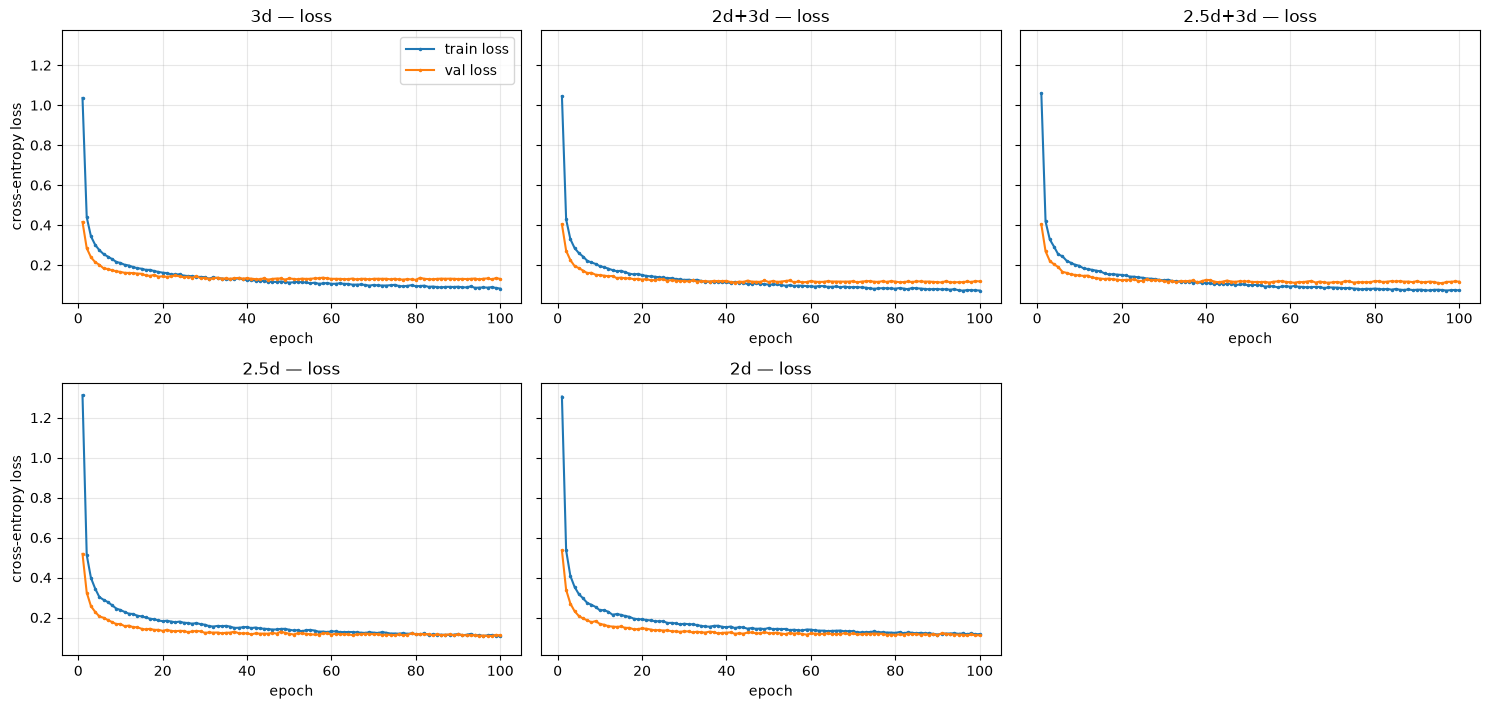

3d: final train 0.0822   val 0.1305
2d+3d: final train 0.0726   val 0.1181
2.5d+3d: final train 0.0730   val 0.1171
2.5d: final train 0.1056   val 0.1105
2d: final train 0.1171   val 0.1111


In [21]:
ncols = min(3, len(MODES))
nrows = -(-len(MODES) // ncols)                 # ceil: wrap onto more rows
# sharey so the panels are comparable by eye, which is the point of putting them
# side by side; a curve that sits higher really is a worse loss.
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows),
                         sharey=True, squeeze=False)
for k, (ax, mode) in enumerate(zip(axes.flat, MODES)):
    _, h, _, _ = SHOWN[mode]
    ax.plot(range(1, len(h["loss"]) + 1), h["loss"], marker=".", ms=3, label="train loss")
    ax.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], marker=".", ms=3,
            label="val loss")
    ax.set_xlabel("epoch")
    ax.set_title(f"{mode} \u2014 loss")
    ax.grid(alpha=0.3)
    if k % ncols == 0:
        ax.set_ylabel("cross-entropy loss")
    if k == 0:
        ax.legend()
for ax in axes.flat[len(MODES):]:               # blank any leftover panel
    ax.axis("off")
fig.tight_layout()
plt.show()

for mode in MODES:
    _, h, _, _ = SHOWN[mode]
    print(f"{mode}: final train {h['loss'][-1]:.4f}   val {h['val_loss'][-1]:.4f}")

## 2. Train / validation accuracy

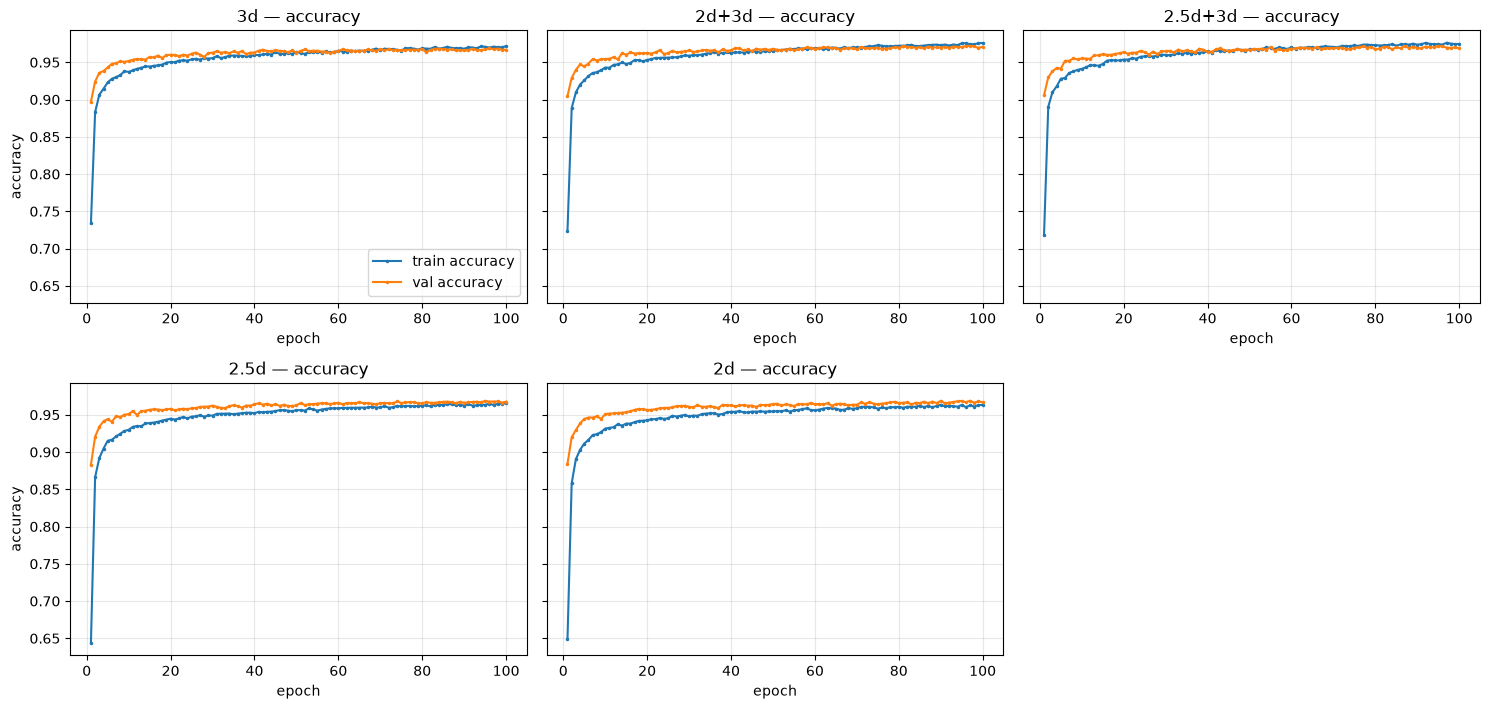

3d: final train 0.9717   val 0.9669
2d+3d: final train 0.9760   val 0.9709
2.5d+3d: final train 0.9747   val 0.9687
2.5d: final train 0.9657   val 0.9676
2d: final train 0.9633   val 0.9667


In [22]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows),
                         sharey=True, squeeze=False)
for k, (ax, mode) in enumerate(zip(axes.flat, MODES)):
    _, h, _, _ = SHOWN[mode]
    ax.plot(range(1, len(h["accuracy"]) + 1), h["accuracy"], marker=".", ms=3,
            label="train accuracy")
    ax.plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], marker=".", ms=3,
            label="val accuracy")
    ax.set_xlabel("epoch")
    ax.set_title(f"{mode} \u2014 accuracy")
    ax.grid(alpha=0.3)
    if k % ncols == 0:
        ax.set_ylabel("accuracy")
    if k == 0:
        ax.legend(loc="lower right")
for ax in axes.flat[len(MODES):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

for mode in MODES:
    _, h, _, _ = SHOWN[mode]
    print(f"{mode}: final train {h['accuracy'][-1]:.4f}   "
          f"val {h['val_accuracy'][-1]:.4f}")

## 3. Per-class precision / recall / F1 on `test_set`

In [16]:
for mode in MODES:
    it, _, yt, yp = SHOWN[mode]
    labels = sorted(set(yt))
    rep = classification_report(yt, yp, labels=labels, zero_division=0,
                                output_dict=True)

    print(f"{mode} on test_set \u2014 accuracy {accuracy_score(yt, yp):.4f} "
          f"({len(yt)} samples, iteration {it})")
    display(pd.DataFrame(
        {c: {"precision": rep[c]["precision"], "recall": rep[c]["recall"],
             "f1-score": rep[c]["f1-score"], "support": int(rep[c]["support"])}
         for c in labels}).T.round(3))

3d on test_set — accuracy 0.7547 (905 samples, iteration 0)


,precision,recall,f1-score,support
A,0.425,0.886,0.574,35.0
B,0.969,0.838,0.899,37.0
C,0.875,0.946,0.909,37.0
D,0.513,0.541,0.526,37.0
E,0.660,0.846,0.742,39.0
F,0.970,0.821,0.889,39.0
G,0.717,0.950,0.817,40.0
H,0.841,0.925,0.881,40.0
I,0.895,0.872,0.883,39.0
K,0.900,0.675,0.771,40.0


2d+3d on test_set — accuracy 0.6961 (905 samples, iteration 1)


,precision,recall,f1-score,support
A,0.465,0.571,0.513,35.0
B,0.969,0.838,0.899,37.0
C,0.829,0.919,0.872,37.0
D,0.500,0.486,0.493,37.0
E,0.485,0.846,0.617,39.0
F,0.969,0.795,0.873,39.0
G,0.828,0.600,0.696,40.0
H,1.000,0.750,0.857,40.0
I,0.846,0.846,0.846,39.0
K,0.821,0.800,0.810,40.0


2.5d+3d on test_set — accuracy 0.6807 (905 samples, iteration 4)


,precision,recall,f1-score,support
A,0.491,0.800,0.609,35.0
B,1.000,0.811,0.896,37.0
C,0.698,0.811,0.750,37.0
D,0.654,0.459,0.540,37.0
E,0.453,0.872,0.596,39.0
F,1.000,0.667,0.800,39.0
G,0.649,0.600,0.623,40.0
H,0.919,0.850,0.883,40.0
I,0.729,0.897,0.805,39.0
K,0.903,0.700,0.789,40.0


2.5d on test_set — accuracy 0.4718 (905 samples, iteration 3)


,precision,recall,f1-score,support
A,0.295,0.886,0.443,35.0
B,0.508,0.811,0.625,37.0
C,0.750,0.243,0.367,37.0
D,0.333,0.189,0.241,37.0
E,0.344,0.821,0.485,39.0
F,1.000,0.282,0.440,39.0
G,0.286,0.050,0.085,40.0
H,1.000,0.350,0.519,40.0
I,0.765,0.667,0.712,39.0
K,0.683,0.700,0.691,40.0


2d on test_set — accuracy 0.4055 (905 samples, iteration 1)


,precision,recall,f1-score,support
A,0.333,0.114,0.170,35.0
B,0.733,0.892,0.805,37.0
C,0.909,0.270,0.417,37.0
D,0.778,0.189,0.304,37.0
E,0.296,0.744,0.423,39.0
F,1.000,0.615,0.762,39.0
G,0.200,0.025,0.044,40.0
H,1.000,0.125,0.222,40.0
I,0.651,0.718,0.683,39.0
K,0.762,0.400,0.525,40.0


## 4. Confusion matrix on `test_set`

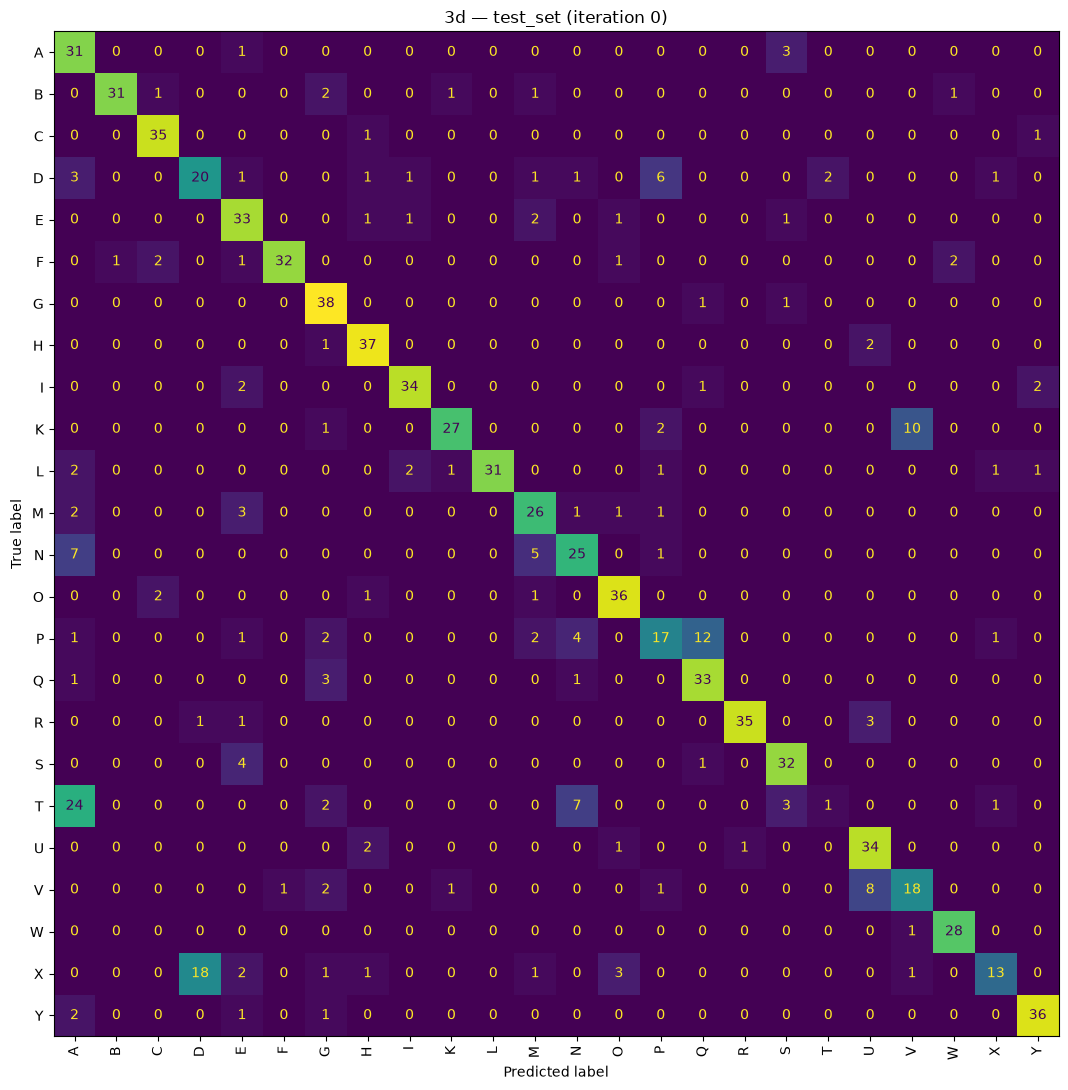

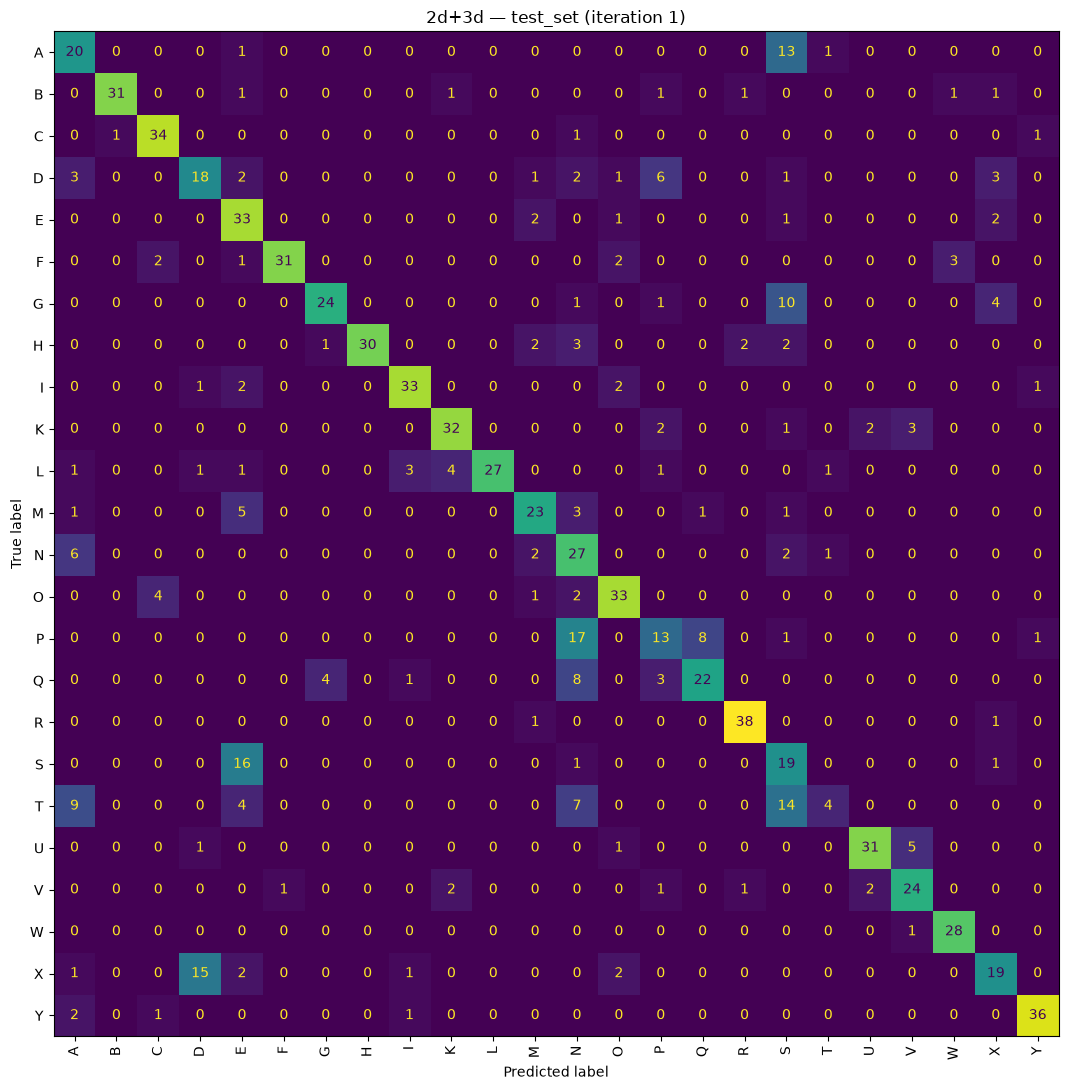

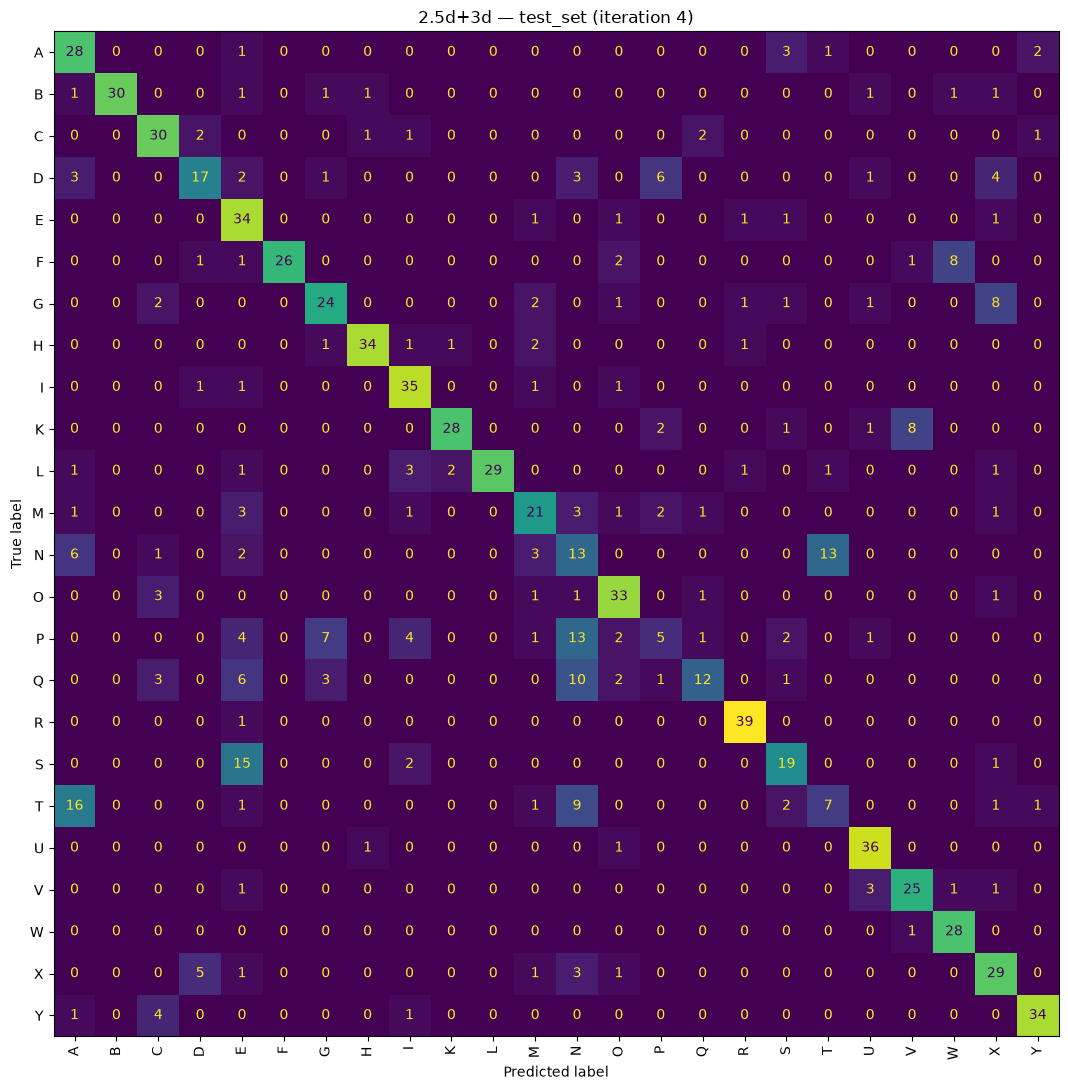

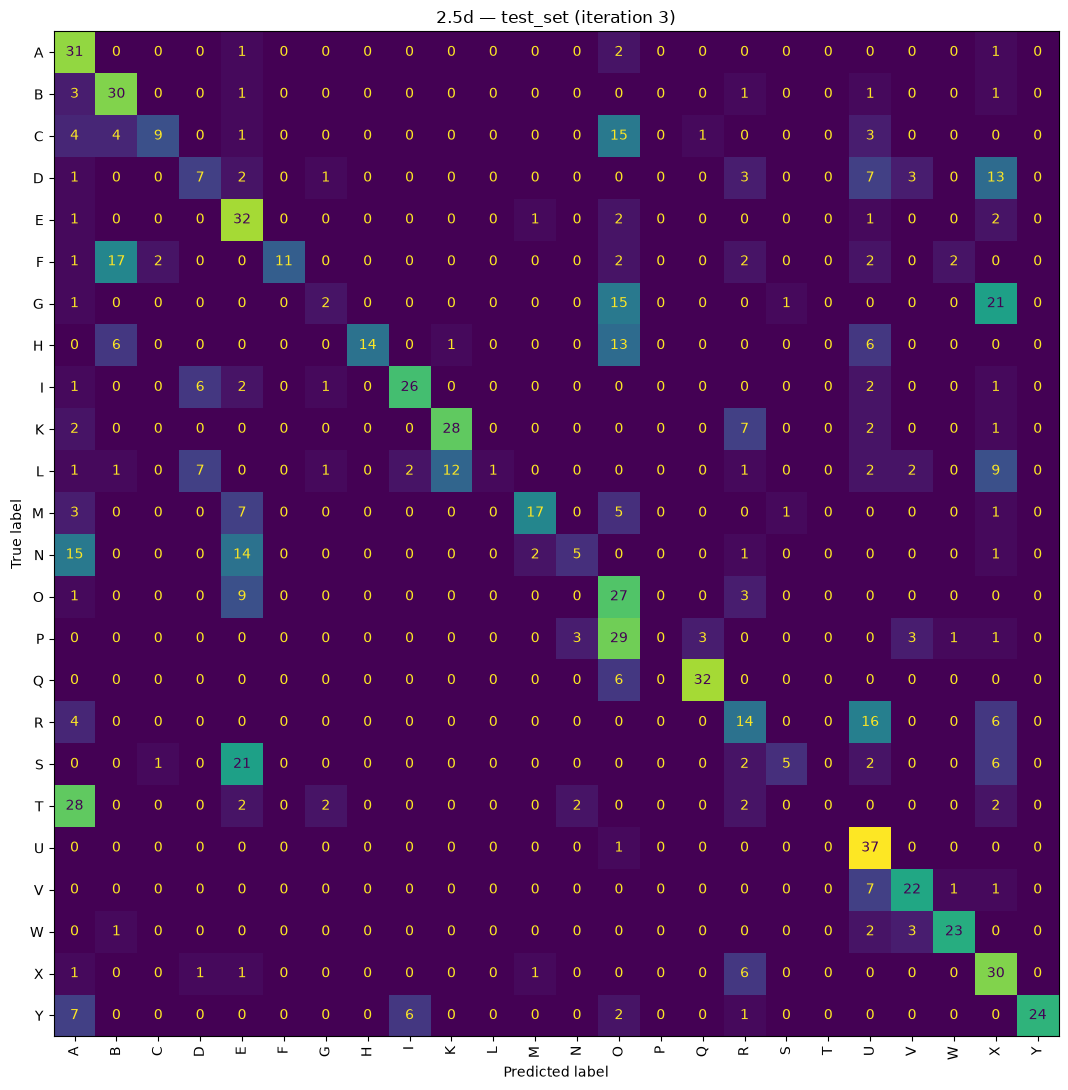

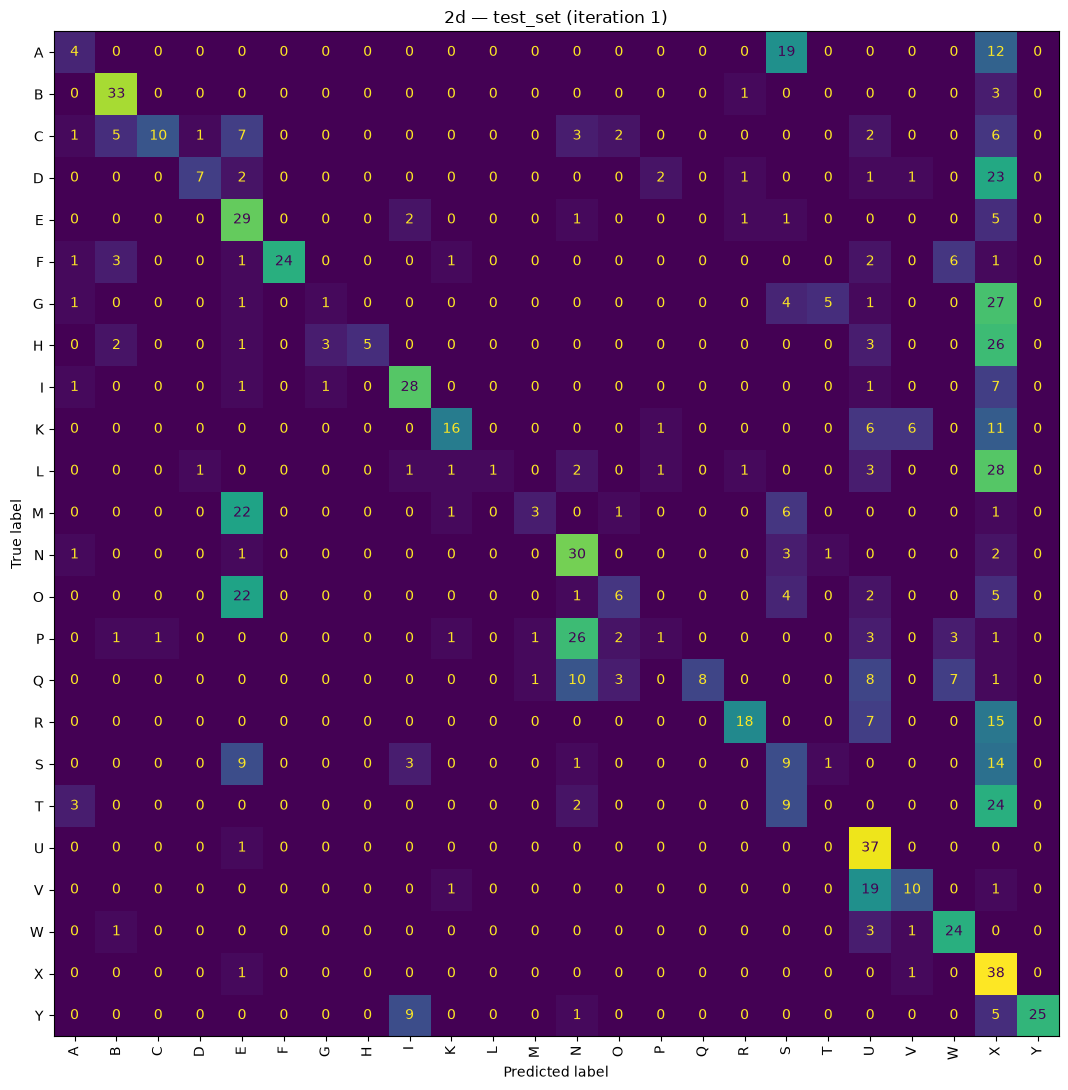

In [17]:
for mode in MODES:
    it, _, yt, yp = SHOWN[mode]
    fig, ax = plt.subplots(figsize=(11, 11))
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, labels=sorted(set(yt)), ax=ax,
        colorbar=False, xticks_rotation="vertical", values_format="d")
    ax.set_title(f"{mode} \u2014 test_set (iteration {it})")
    fig.tight_layout()
    plt.show()

## 5. Overall accuracy, all feature modes

Final `test_set` accuracy of each mode, averaged over its `ITERATIONS` runs.

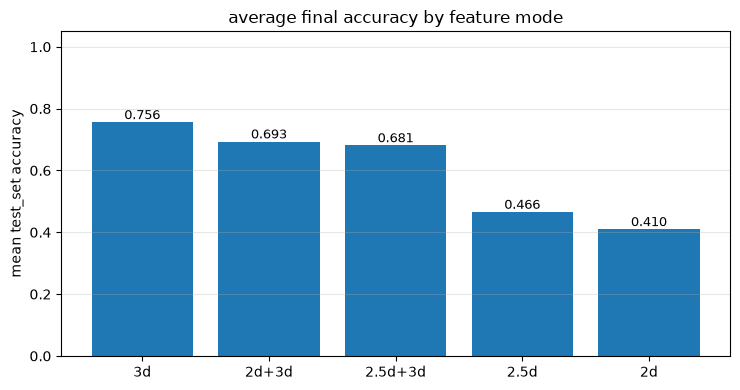

,mean test_set accuracy
3d,0.7560
2d+3d,0.6935
2.5d+3d,0.6813
2.5d,0.4659
2d,0.4099


In [18]:
avg = pd.Series({m: np.mean(d["accuracy"]) for m, d in res.items()}
                ).sort_values(ascending=False)
# the same average, but of each iteration's final TRAIN accuracy. Bars keep the
# test_set order in both charts so the two are read side by side.
avg_train = pd.Series({m: np.mean([h["accuracy"][-1] for h in d["histories"]])
                       for m, d in res.items()})[avg.index]

for series, name, col in ((avg, "test_set", "C0"), (avg_train, "train", "C1")):
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(series.index, series.values, color=col)
    for k, v in enumerate(series):
        ax.text(k, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    ax.set_ylabel(f"mean {name} accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"average final {name} accuracy by feature mode")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

avg.to_frame("mean test_set accuracy").round(4)

## 6. Model architecture

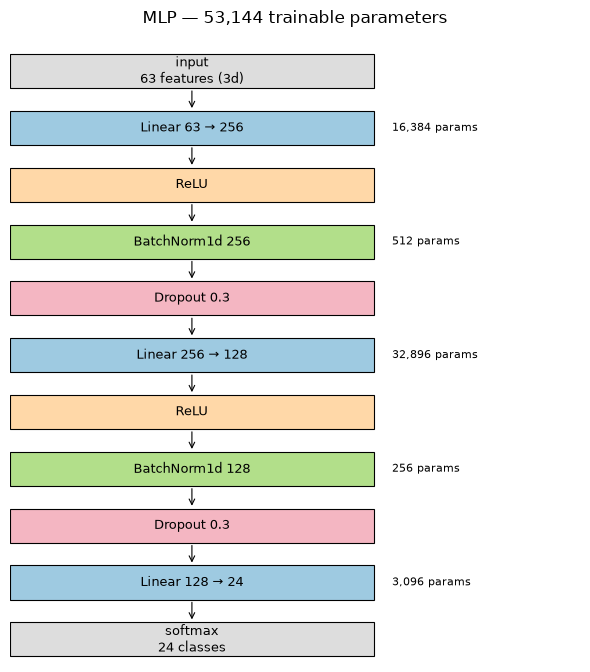

Adam lr 0.001 | cross-entropy loss | 100 epochs | batch 256 | seeded 20% validation split
input dims: 2.5d+3d = 126, 2.5d = 63, 2d+3d = 105, 2d = 42, 3d = 63


In [19]:
# Drawn from config.py (HIDDEN_LAYERS / BATCH_NORM / DROPOUT), so it reflects the
# CURRENT config -- edit those after training and this stops matching the runs above.
# The input width is the only thing that differs between feature modes, so every
# mode's width is spelled out in the input box and the rest of the net is shared.
n_classes = len(set(SHOWN[MODES[0]][2]))
widths = "   ".join(f"{m} {res[m]['dims']}"
                    for m in sorted(res, key=lambda m: res[m]["dims"]))

boxes = [(f"input features\n{widths}", "io"), (f"Linear \u2192 {cfg.HIDDEN_LAYERS[0]}", "lin")]
for k, h in enumerate(cfg.HIDDEN_LAYERS):
    if k:
        boxes.append((f"Linear {cfg.HIDDEN_LAYERS[k - 1]} \u2192 {h}", "lin"))
    boxes.append(("ReLU", "act"))
    if cfg.BATCH_NORM:
        boxes.append((f"BatchNorm1d {h}", "bn"))
    if cfg.DROPOUT > 0:
        boxes.append((f"Dropout {cfg.DROPOUT}", "drop"))
boxes.append((f"Linear {cfg.HIDDEN_LAYERS[-1]} \u2192 {n_classes}", "lin"))
boxes.append((f"softmax\n{n_classes} classes", "io"))

colour = {"io": "#dddddd", "lin": "#9ecae1", "act": "#ffd8a8",
          "bn": "#b2df8a", "drop": "#f4b6c2"}
fig, ax = plt.subplots(figsize=(5.5, 0.62 * len(boxes)))
for k, (name, kind) in enumerate(boxes):
    y = len(boxes) - 1 - k                      # first box at the top
    ax.add_patch(plt.Rectangle((0, y), 3, 0.6, facecolor=colour[kind],
                               edgecolor="black", lw=0.8))
    ax.text(1.5, y + 0.3, name, ha="center", va="center",
            fontsize=8 if len(name) > 28 else 9)
    if k:                                       # arrow down from the box above
        ax.annotate("", xy=(1.5, y + 0.6), xytext=(1.5, y + 1.0),
                    arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.1, len(boxes))
ax.axis("off")
ax.set_title(f"MLP \u2014 {n_classes} classes")
fig.tight_layout()
plt.show()

print("Adam lr", cfg.LEARNING_RATE, "| cross-entropy loss |", cfg.EPOCHS, "epochs |",
      f"batch {cfg.BATCH_SIZE} | seeded {cfg.VAL_SPLIT:.0%} validation split")

---
### Reference (no output, just notes)

**Model.** `input -> [Linear -> ReLU -> BatchNorm -> Dropout(0.3)] x2 -> Linear -> softmax`,
hidden `(256, 128)`, 24 outputs. Adam lr 1e-3, cross-entropy, 100 epochs, batch 256,
seeded 20% validation split. Inputs standardized per dimension on the training split.
Weights export to numpy (`neural_network/asl_mlp.py`) with BatchNorm folded into the
next Linear, so `app.py` needs no torch.

**Feature modes.** `2d` = 42 image x,y - `2.5d` = 63 image x,y,z - `3d` = 63 world
landmarks min-maxed to [0,1] - `2d+3d` = 105 - `2.5d+3d` = 126. Left hands are mirrored
to right chirality first (`FLIP_LEFT_TO_RIGHT`).

**jazz.** jazz's `hand_landmark_224_full_int8.tflite` is the same network MediaPipe
Tasks bundles in our `hand_landmarker.task` - fed identical input the two agree to ~1e-5
on all four heads, once hand-pose's baked scalings (`landmarks` x 1/224, `world` x 13)
are undone. Differences are ours, not the model's: jazz crops its own palm ROI where we
use MediaPipe's palm detector, and jazz recenters on the wrist where we min-max.

**Caveat.** Mirroring uses MediaPipe's *predicted* handedness, which disagrees with the
`left`/`right` folder on ~5% of `test_set`. That is deliberate - live jazz has no folder
either - but it puts a ceiling on achievable accuracy.